In [11]:
import sys
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "Pipfile").exists()),
    Path("../../..").resolve(),
)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from load_data.load_conformal_data import load_conformance_results
from conformance_analysis.risk_model import DataFrameConstruction, ConformalAnalysisVisualizations, LogisticRegressionModel
from conformance_analysis.deviation_model import DeviationPredictionCalibration

print("Project root:", PROJECT_ROOT)

Project root: /Users/laurensohl/Downloads/Gitarre/Akademia/Master_Arbeit/Conformance Checking Mustroph


# Load the calibration dataset

In [12]:
# Load the validation fitness score results:

# Helpdesk
path_fitness_results = PROJECT_ROOT / "data" / "Helpdesk" / "proact_conf_check_v2" / "offline_analysis"
# New path: store model
path_model = "./results/Helpdesk/crc_logistic_model.pkl"
# New path: store calibration results
path_dev_threshs = "./results/Helpdesk/deviation_labels_thresholds.json"

# Sepsis
# path_fitness_results = PROJECT_ROOT / "data" / "Sepsis" / "proact_conf_check_v2" / "offline_analysis"
# New path: store model
# path_model = "./results/Sepsis/crc_logistic_model.pkl"
# New path: store calibration results
# path_dev_threshs = "./results/Sepsis/deviation_labels_thresholds.json"

# BPIC20:
# path_fitness_results = PROJECT_ROOT / "data" / "BPIC20" / "proact_conf_check_v2" / "offline_analysis"
# New path: store model
# path_model = "./results/BPIC20/crc_logistic_model.pkl"
# New path: store calibration results
# path_dev_threshs = "./results/BPIC20/deviation_labels_thresholds.json"

# Repair:
# path_fitness_results = PROJECT_ROOT / "data" / "repair_shop" / "proact_conf_check_v2" / "offline_analysis"
# New path: store model
# path_model = "./results/Repair/crc_logistic_model.pkl"
# New path: store calibration results
# path_dev_threshs = "./results/Repair/deviation_labels_thresholds.json"


In [13]:
# All results of Prob. Suffix Pred. + Alignment-Based Conformance Checking:
# uses only the D_risk set
# Loads the results of the conformance checking for all cases.
# conformance_res_050.pkl
# conformance_res_100.pkl
# conformance_res_150.pkl
risk_data_results = load_conformance_results(path=path_fitness_results)

# risk_data_results = {
#     "case_id": [...],
#     "target_conformance": [...],
# target_conformance = {
#     "prefix": ["A", "B", "C"],
#     "target_suffix": ["D", "E", "F"],
#     "alignment": [...],
#     "suffix_fitness": 0.92,
#     "fitness": 0.95,
#     "cost": 10000,
#     ...
# }
#     "ml_conformance": [...], MOST LIKELY
# ml_conformance = {
#     "prefix": ["A", "B", "C"],
#     "ml_suffix": ["D", "F"],
#     "alignment": [...],
#     "suffix_fitness": 0.78,
#     ...
# }
#  "samples_conformance": [...]
# }
# samples_conformance = [
#     {
#         "sampled_suffix": ["D", "E", "F"],
#         "suffix_fitness": 1.00,
#         "alignment": [...],
#         ...
#     },
#     {
#         "sampled_suffix": ["D", "F"],
#         "suffix_fitness": 0.82,
#         "alignment": [...],
#         ...
#     },
#     {
#         "sampled_suffix": ["G", "F"],
#         "suffix_fitness": 0.48,
#         "alignment": [...],
#         ...
#     },
#     ...
# ]

# Case ids
res_case_id = risk_data_results['case_id']
# Target conformance results
res_target_conf = risk_data_results['target_conformance']
res_target_conf_suffix_fit = [res['suffix_fitness'] for res in res_target_conf]
# Most-likely
res_ml_conf = risk_data_results['ml_conformance']
res_ml_conf_suffix_fit = [res['suffix_fitness'] for res in res_ml_conf]
# Samples
res_smpl_conf = risk_data_results['samples_conformance']
res_smpl_conf_suffix_fit = [[r['suffix_fitness'] for r in res] for res in res_smpl_conf]

Looking for .pkl files in: /Users/laurensohl/Downloads/Gitarre/Akademia/Master_Arbeit/Conformance Checking Mustroph/data/Helpdesk/proact_conf_check_v2/offline_analysis
Resolved absolute path: /Users/laurensohl/Downloads/Gitarre/Akademia/Master_Arbeit/Conformance Checking Mustroph/data/Helpdesk/proact_conf_check_v2/offline_analysis
Found 1 files
Loaded all conformance results!


In [22]:
risk_data_results["target_conformance"]

[{'prefix': ['Assign seriousness'],
  'target_suffix': ['Take in charge ticket',
   'Take in charge ticket',
   'Resolve ticket',
   'Closed'],
  'alignment': [('>>', None),
   ('>>', None),
   ('>>', None),
   ('Assign seriousness', 'Assign seriousness'),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('Take in charge ticket', 'Take in charge ticket'),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('Take in charge ticket', 'Take in charge ticket'),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('Resolve ticket', 'Resolve ticket'),
   ('>>', None),
   ('>>', None),
   ('Closed', 'Closed'),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None),
   ('>>', None)],
  'prefix_alignment': [('>>', None),
   ('>>', None),
   ('>>', None),
   ('Assign seriousness', 'Assign seriousness')],
  'suffix_alignment'

In [14]:
# Design choices:
# Set q-level (percentage of suffix samples to check with alpha risk lower fitness score) of risk safe and determine r_q (fitness value):
# e.g.: the 95% percent worst
alpha_risk = 0.95

# Set alpha for logistic regression calibration: for example with prob: 1-alpha, I ensure that my prd lies in the right set.
alpha_expected_loss = 0.05
# alpha_expected_loss = 0.15
# alpha_expected_loss = 0.25

# Build dataframe for risk-controlled conformance model

In [15]:
# Create dataframe for training and calibration datasets:
dc = DataFrameConstruction(conformance_results=risk_data_results)

# Emprical Alpha qunatiles for (suffix) fitness score thresholds:
alpha_risk = alpha_risk

# change aggregation to 'mean'
# Für jeden Case werden die vielen suffix_fitness-Werte der gesampelten PSP-Suffixe zu einem einzigen Wert zusammengefasst — und zwar mit dem Median.
aggregation_samples = 'median'

# Compute based on alpha the suffix fitness values:
emp_results = dc.empirical_quantile_thresholds(alpha_risk=alpha_risk, 
                                               aggregation=aggregation_samples)
print("Empirical risk value results: ", emp_results)

Empirical risk value results:  {'target': {'q_risk': 1.0}, 'most_likely': {'q_risk': 1.0}, 'samples': {'q_risk': 1.0, 'mean_std': np.float64(0.03714701413401966)}}


Aggregated samples fitness statistics: n=20, mean=0.9592, median=1.0000, std=0.0958, Q1=1.0000, Q3=1.0000
Target fitness statistics: n=20, mean=1.0000, median=1.0000, std=0.0000, Q1=1.0000, Q3=1.0000
Risk threshold fitness score:  1.0
Error in KDE computation: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.


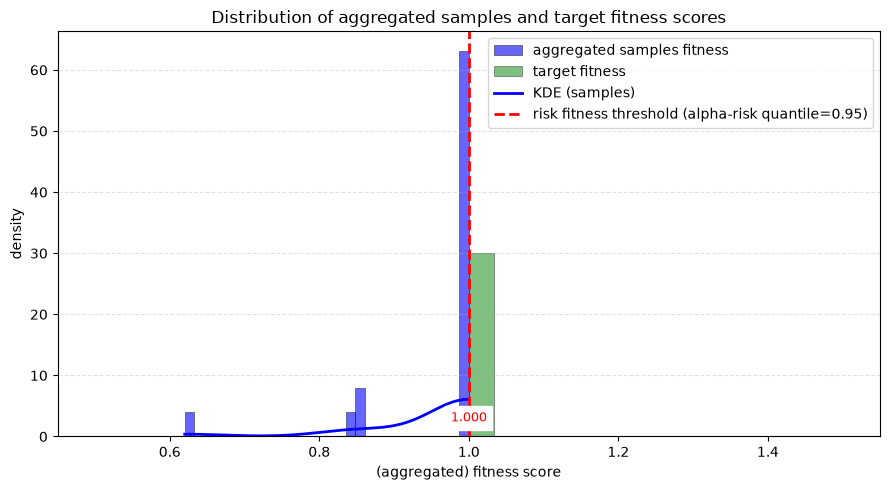

In [16]:
# Suffix fitness score distribution
cav = ConformalAnalysisVisualizations(sampled_fitness=res_smpl_conf_suffix_fit,
                                      target_fitness=res_target_conf_suffix_fit,
                                      ml_fitness=res_ml_conf_suffix_fit)
  
# Empirical distribution of fitness scores and quantile thresholds:
# ! Only the target fitness per case is used to determine if a case is risk or safe
q_risk = cav.plot_distribution(alpha_risk=alpha_risk,
                               # Print median aggregated sampled fitness scores distribution:
                               aggregation=aggregation_samples)

In [ ]:
# Create dataframe for training and calibration datasets:
dc = DataFrameConstruction(conformance_results=risk_data_results)

# Add as threshold the determined q_risk
df = dc.samples_to_dataframe(q_risk=q_risk,
                             target_col='y_safe_case',
                             include_tail_features=True)
# All values that have fitness >= risk threshold are save!
print(df.head(5))

# Suppose df is your dataframe and 'y' is the target column
X = df.drop(columns='y_safe_case')
# 1 = safe, 0 = risk
y = df['y_safe_case']

# Split the conformance calibration dataframe into train (train log reg on that) and conformal calibration (calibrate log reg) datsets:
X_train, X_cal, y_train, y_cal = train_test_split(X,
                                                  y, 
                                                  test_size=0.2,      # 20% of all data in total.
                                                  random_state=42,    # ensures reproducibility,
                                                  stratify=y          # optional: keeps class balance if classification
                                                  )
print("Shape of train and calibration sets:", X_train.shape, X_cal.shape)

    mean  variance       std  skewness  kurtosis_excess  median   min  max  \
0  0.834  0.011544  0.107443  0.081114        -0.960815   0.845  0.67  1.0   
1  0.887  0.005781  0.076033  0.695163        -1.265425   0.860  0.80  1.0   
2  0.916  0.004704  0.068586  0.408248        -1.833333   0.860  0.86  1.0   
3  1.000  0.000000  0.000000  0.000000        -3.000000   1.000  1.00  1.0   
4  0.986  0.001764  0.042000 -2.666667         5.111111   1.000  0.86  1.0   

    q25     q75     iqr     q05    q10  q90  q95  p_below_qrisk  \
0  0.74  0.8675  0.1275  0.6880  0.706  1.0  1.0            0.8   
1  0.83  0.9650  0.1350  0.8135  0.827  1.0  1.0            0.7   
2  0.86  1.0000  0.1400  0.8600  0.860  1.0  1.0            0.6   
3  1.00  1.0000  0.0000  1.0000  1.000  1.0  1.0            0.0   
4  1.00  1.0000  0.0000  0.9230  0.986  1.0  1.0            0.1   

   mean_below_qrisk  shortfall_below_qrisk  y_safe_case  
0          0.792500               0.207500            1  
1          0

## Train risk classifier model

In [18]:
# Logistic regression model training:
df_train = X_train.copy()
df_train['y_safe_case'] = y_train

lm = LogisticRegressionModel(alpha_quantile_risk=alpha_risk, risk_fitness_threshold=q_risk)
lm.fit_from_dataframe(df_train, target_col='y_safe_case', calibrate=False)
print('model intercept :', lm.classifier.intercept_)
print('model coefficients : ', lm.classifier.coef_)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

In [10]:
# Prediction accuracy on conformal calibration subset of full calibration set:
# Calibration dataframe
df_cal = X_cal.copy()
df_cal['y_safe_case'] = y_cal

cal_score = lm.pipeline.score(X_cal, y_cal)
print("Cal accuracy:", cal_score)

# Preditcition probabilities on train and cal sets:
y_prob_cal = lm.pipeline.predict_proba(X_cal)[:,1]

plt.hist(y_prob_cal, bins=20, alpha=0.5, label='Cal')
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.legend()
plt.show()

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

## Calibrate the model using conformal risk control and save

In [ ]:
# Conformal prediction calibration:
cal_res = lm.calibrate_conformal_threshold(X_cal=df_cal.drop(columns='y_safe_case'),
                                           y_cal=df_cal['y_safe_case'],
                                           alpha=alpha_expected_loss)

# Use CRC to control false-safe rate among predicted-safe cases
# cal_res = lm.calibrate_crc_safe_threshold(X_cal=df_cal.drop(columns='y_safe_case'),
#                                           y_cal=df_cal['y_safe_case'],
#                                           alpha=alpha_expected_loss)

print(f"All cases predicted with p >= {lm.calibration_info['threshold']} are classified as safe.")

# Save the model
lm.save(path_model)

## Calibrate binary prediction on deviation labels

In [ ]:
# Calibrate the deviation predictions for all labels using the F_beta score:
# Create dataframe for risk examples only:
dc = DataFrameConstruction(conformance_results=risk_data_results) 

# Add as threshold the determined q_risk fitness score that is stored in the logistic regression model, to generate the targets
# lm.calibration_info['threshold'] is a *probability* threshold (for predicting safe), not a fitness threshold.
df = dc.samples_to_dataframe(q_risk=lm.risk_fitness_threshold,
                             target_col='y_safe_case',
                             include_tail_features=True)

# Get all cases that are risk and count therefore for deviation prediction:
risks = {'case_id': [],
         'target_conformance': [],
         'ml_conformance': [],
         'samples_conformance': []} 

labels, probs = lm.predict_with_threshold(X=df)

for i in range(len(labels)):
    if labels[i] == 0:
        risks['case_id'].append(res_case_id[i])
        risks['target_conformance'].append(res_target_conf[i])
        risks['ml_conformance'].append(res_ml_conf[i])
        risks['samples_conformance'].append(res_smpl_conf[i])

In [ ]:
# Compute deviation label thresholds        
dpc = DeviationPredictionCalibration(risk_conformance_results=risks)

deviation_thresholds = dpc.find_optimal_thresholds(preference='balanced')
print("Calibrated deviation label thresholds for deviation prediction:", deviation_thresholds)
print("if p(case) -> risk -> p(dev) >= t -> predicted as TRUE")

dpc.save(path=path_dev_threshs, thresholds=deviation_thresholds)